<a href="https://colab.research.google.com/github/laramalkawi81-ops/ML-DBSCAN-PCA/blob/main/Copy_of_Untitled29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [20]:
import pandas as pd
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [22]:

df = df.drop(['Id', 'Species'], axis=1)

# missing values
print(df.isnull().sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


#SCALING

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

We removed non-numeric columns (Id and Species) because DBSCAN is an unsupervised algorithm.
We checked for missing values and applied standardization to ensure all features have equal scale.

PCA

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Explained Variance

In [25]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72770452 0.23030523]
Total Variance Retained: 0.9580097536148199


The PCA results show that the first two principal components retain approximately 95.8% of the total variance.
This indicates that most of the original information is preserved after dimensionality reduction.
Therefore, using 2 components is sufficient for visualization and clustering.

PCA GRAPH

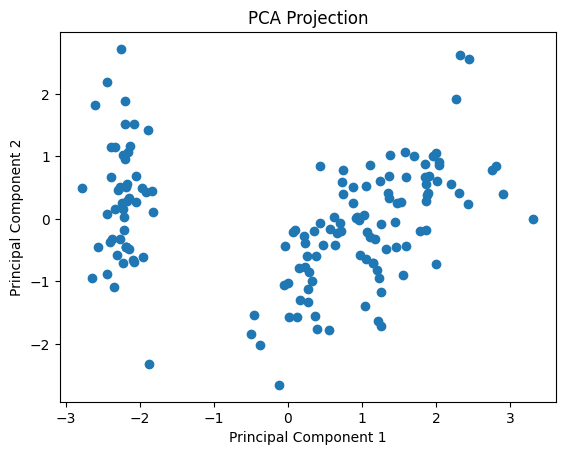

In [26]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

DBSCAN

First experiment (initial values)

In [27]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_original = dbscan.fit_predict(X_scaled)

 know the number of clusters

In [28]:
import numpy as np

n_clusters = len(set(labels_original)) - (1 if -1 in labels_original else 0)
n_noise = list(labels_original).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 35


The initial DBSCAN results on the original dataset produced only 2 clusters with a relatively high number of noise points (35).
This indicates that the chosen parameters may not be optimal and require tuning to improve clustering performance.

Plot the results

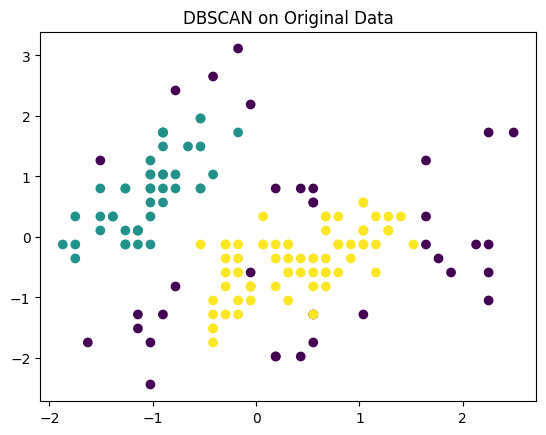

In [29]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_original)
plt.title("DBSCAN on Original Data")
plt.show()


TUNING

In [30]:
for eps in [0.3, 0.5, 0.7, 0.9, 1.2]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps} -> clusters={n_clusters}, noise={n_noise}")

eps=0.3 -> clusters=3, noise=120
eps=0.5 -> clusters=2, noise=35
eps=0.7 -> clusters=2, noise=8
eps=0.9 -> clusters=2, noise=4
eps=1.2 -> clusters=2, noise=1


Best balance
eps = 0.7

Different values of eps were tested to optimize DBSCAN performance.
At eps = 0.7, the model produced a reasonable number of clusters with reduced noise points.
However, the algorithm still did not perfectly separate the dataset into 3 clusters, which highlights a limitation of DBSCAN on the original high-dimensional data.

After testing multiple values of eps, the best performance was achieved at eps = 0.7.
This value provides a good balance between the number of clusters and noise points.

Final Number of clusters: 2
Final Number of noise points: 8


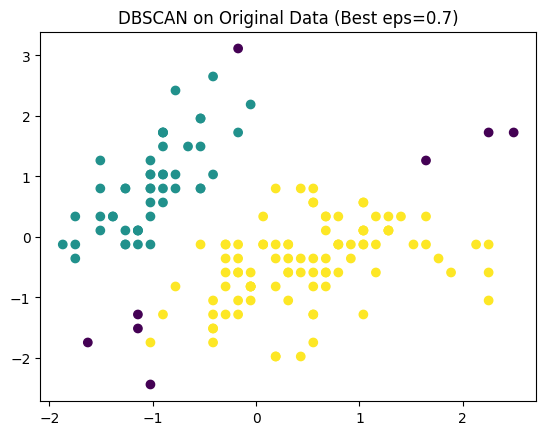

In [31]:
# Best DBSCAN model after tuning
dbscan = DBSCAN(eps=0.7, min_samples=5)
labels_original = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_original)) - (1 if -1 in labels_original else 0)
n_noise = list(labels_original).count(-1)

print("Final Number of clusters:", n_clusters)
print("Final Number of noise points:", n_noise)


plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_original)
plt.title("DBSCAN on Original Data (Best eps=0.7)")
plt.show()

After tuning the DBSCAN parameters, the best result on the original dataset was obtained using eps = 0.7.
The model produced 2 clusters with 8 noise points.
Although the noise was reduced compared to other values, the clustering did not perfectly separate the data into 3 clusters.

Apply DBSCAN on PCA results

In [32]:
dbscan_pca = DBSCAN(eps=0.5, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

In [33]:
n_clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise_pca = list(labels_pca).count(-1)

print("PCA Clusters:", n_clusters_pca)
print("PCA Noise:", n_noise_pca)

PCA Clusters: 2
PCA Noise: 12


Graphe

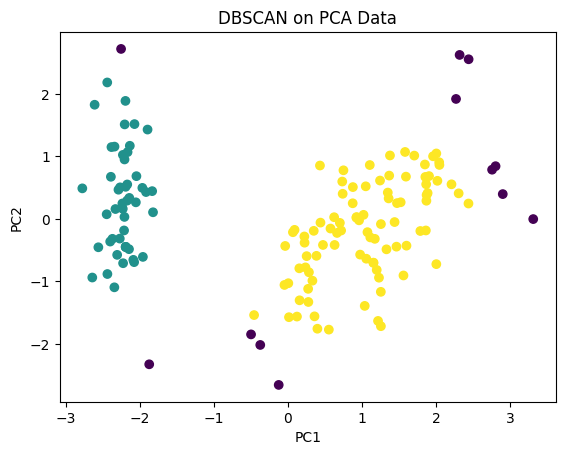

In [34]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.title("DBSCAN on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [35]:
for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps} -> clusters={n_clusters}, noise={n_noise}")

eps=0.3 -> clusters=5, noise=34
eps=0.4 -> clusters=2, noise=20
eps=0.5 -> clusters=2, noise=12
eps=0.6 -> clusters=2, noise=6
eps=0.7 -> clusters=2, noise=5


Final PCA Clusters: 2
Final PCA Noise: 5


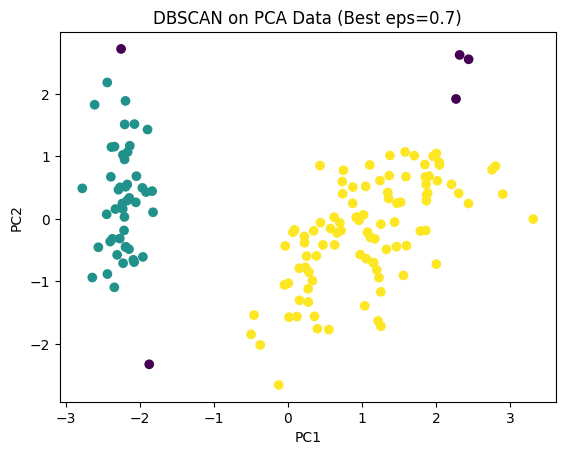

In [36]:
# Best DBSCAN on PCA after tuning
dbscan_pca = DBSCAN(eps=0.7, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

n_clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise_pca = list(labels_pca).count(-1)

print("Final PCA Clusters:", n_clusters_pca)
print("Final PCA Noise:", n_noise_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.title("DBSCAN on PCA Data (Best eps=0.7)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

After applying DBSCAN on the PCA-reduced dataset and tuning the parameters, the best result was achieved at eps = 0.7.
The model produced 2 clusters with only 5 noise points, which is an improvement compared to the original dataset.
This shows that PCA helped reduce noise and improved clustering quality.

Comparison of DBSCAN Results Before and After PCA
The table below shows the number of clusters and noise points for DBSCAN applied on the original dataset and after PCA.

| Dataset        | Number of Clusters | Noise Points |
|----------------|-------------------|--------------|
| Original Data  | 2                 | 8            |
| PCA Data       | 2                 | 5            |

A comparison between DBSCAN results before and after PCA shows that PCA improved clustering performance.

On the original dataset, DBSCAN produced 2 clusters with 8 noise points.
After applying PCA, the number of clusters remained the same, but the number of noise points decreased to 5.

This indicates that PCA helped in reducing noise and improving the structure of the data, making clusters more compact and easier to detect.

However, DBSCAN was still unable to perfectly identify the expected 3 clusters, which highlights a limitation of the algorithm for this dataset.